In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  root_mean_squared_error , r2_score , mean_absolute_error
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib

In [3]:
df=pd.read_csv('../data/almaty_housing_dataset.csv')

In [4]:
df.head()

,latitude,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,district,building_type,floor,total_floors,ceiling_height,rooms,total_area,metro_distance_km,proximity
0,43.2500,76.9751,3.9,2,2,146,71,59.4378,57052454.3,Бостандыкский,панельный,3,16,2.59,2,57.3,5.91,ГОРЫ
1,43.3233,76.9412,20.5,1,1,72,25,51.9898,26030799.5,Турксибский,панельный,7,16,2.52,1,40.3,3.70,ОКРАИНА
2,43.3244,76.8898,3.7,3,2,132,53,50.8767,39670076.9,Турксибский,панельный,2,5,3.09,2,53.1,6.04,ОКРАИНА
3,43.3737,76.8888,5.5,3,1,101,39,50.8748,20994180.3,Турксибский,панельный,2,9,2.81,1,37.0,10.89,ОКРАИНА
4,43.3004,76.9615,12.3,4,3,98,39,24.5934,45134327.6,Турксибский,панельный,15,20,2.85,3,61.9,2.66,ОКРАИНА


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            5000 non-null   float64
 1   longitude           5000 non-null   float64
 2   housing_median_age  5000 non-null   float64
 3   total_rooms         5000 non-null   int64  
 4   total_bedrooms      5000 non-null   int64  
 5   population          5000 non-null   int64  
 6   households          5000 non-null   int64  
 7   median_income       5000 non-null   float64
 8   median_house_value  5000 non-null   float64
 9   district            5000 non-null   str    
 10  building_type       5000 non-null   str    
 11  floor               5000 non-null   int64  
 12  total_floors        5000 non-null   int64  
 13  ceiling_height      5000 non-null   float64
 14  rooms               5000 non-null   int64  
 15  total_area          5000 non-null   float64
 16  metro_distance_km

| Колонка                            | Описание                                                        |
| ---------------------------------- | --------------------------------------------------------------- |
| `latitude` / `longitude`           | Координаты (43.17–43.38, 76.82–77.00)                           |
| `housing_median_age`               | Возраст дома (1–52 лет)                                         |
| `total_rooms`                      | Общее количество комнат                                         |
| `total_bedrooms`                   | Количество спален                                               |
| `population`                       | Население в доме                                                |
| `households`                       | Количество домохозяйств                                         |
| `median_income`                    | Медианный доход (×10,000 KZT)                                   |
| `median_house_value`               | Цена квартиры (KZT)                                             |
| `district`                         | Район (8 районов Алматы)                                        |
| `building_type`                    | Тип здания (панельный/кирпичный/монолитный/каркасно-монолитный) |
| `floor`                            | Этаж                                                            |
| `total_floors`                     | Всего этажей в доме                                             |
| `ceiling_height`                   | Высота потолков (м)                                             |
| `rooms`                            | Количество комнат (1–5)                                         |
| `total_area`                       | Общая площадь (кв.м)                                            |
| `metro_distance_km`                | Расстояние до метро (км)                                        |
| `proximity` / `location_proximity` | Локация (ЦЕНТР/БЛИЗ ЦЕНТРА/СПАЛЬНЫЙ/ОКРАИНА/ГОРЫ)               |


In [6]:
df.shape

(5000, 18)

In [7]:
df.describe()

,latitude,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,floor,total_floors,ceiling_height,rooms,total_area,metro_distance_km
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.273291,76.907260,18.399960,2.772000,2.326400,146.061400,54.048800,48.517411,5.385409e+07,6.854800,12.92720,2.691860,2.326400,65.203180,3.654558
std,0.044020,0.041631,13.759821,1.226669,1.066438,71.632115,28.541264,16.871551,2.702787e+07,4.889304,5.50672,0.238402,1.066438,28.791077,2.729879
min,43.180100,76.820100,1.000000,1.000000,1.000000,31.000000,11.000000,18.599600,9.929840e+06,1.000000,5.00000,2.400000,1.000000,20.000000,0.020000
25%,43.241700,76.881500,6.400000,2.000000,1.000000,93.000000,33.000000,36.349675,3.382353e+07,3.000000,9.00000,2.500000,1.000000,42.300000,1.350000
50%,43.267800,76.906250,14.800000,3.000000,2.000000,130.000000,47.000000,46.176950,4.790635e+07,6.000000,12.00000,2.700000,2.000000,58.500000,2.980000
75%,43.303000,76.937700,27.400000,4.000000,3.000000,185.000000,68.000000,56.778000,6.791016e+07,10.000000,16.00000,2.820000,3.000000,82.525000,5.400000
max,43.379800,76.999800,52.000000,7.000000,5.000000,525.000000,205.000000,115.820700,2.359105e+08,25.000000,25.00000,3.500000,5.000000,193.000000,12.110000


In [8]:
df.isnull().sum()

latitude              0
longitude             0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
district              0
building_type         0
floor                 0
total_floors          0
ceiling_height        0
rooms                 0
total_area            0
metro_distance_km     0
proximity             0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

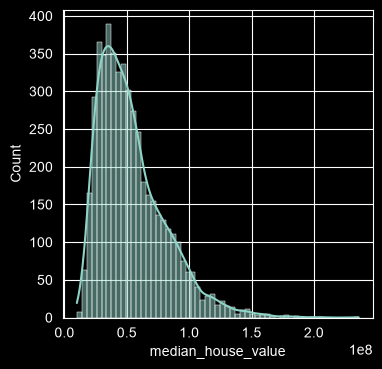

In [10]:
target = 'median_house_value'
plt.figure(figsize=(4,4))
sns.histplot(
    df[target],
    kde=True,
)
plt.show()

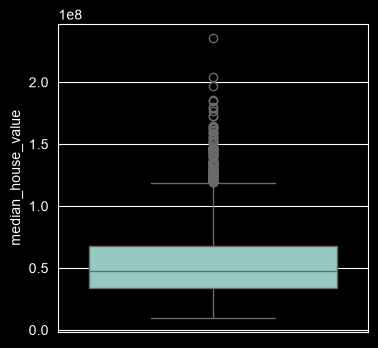

In [11]:
plt.figure(figsize=(4,4))
sns.boxplot(
    df[target], )
plt.show()

In [12]:
df[target].value_counts()

median_house_value
57052454.3    1
26030799.5    1
39670076.9    1
20994180.3    1
45134327.6    1
             ..
31835035.5    1
60361140.9    1
20143824.9    1
29227545.6    1
48414998.6    1
Name: count, Length: 5000, dtype: int64

In [13]:
pd.get_dummies(df["district"])

,Алатауский,Алмалинский,Ауэзовский,Бостандыкский,Жетысуский,Медеуский,Наурызбайский,Турксибский
0,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,True,False,False
4996,False,False,False,False,False,True,False,False
4997,False,False,False,False,False,False,True,False
4998,True,False,False,False,False,False,False,False


In [14]:
y=df[target]
X=df.drop(target,axis=1)
X = pd.get_dummies(X)

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [16]:
rf=RandomForestRegressor(
    n_estimators=150,
    oob_score=True,
    random_state=42,
)

In [17]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print("r2=", r2_score (y_test, y_pred))
print('MAE=', mean_absolute_error (y_test, y_pred))
print("RMSE=", root_mean_squared_error (y_test, y_pred))

r2= 0.9318466995675717
MAE= 5133446.450869999
RMSE= 7097296.165764481


In [18]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
)

In [19]:
model_xgb.fit(X_train, y_train)
y_predxgb = model_xgb.predict(X_test)
print("r2=", r2_score (y_test, y_predxgb))
print('MAE=', mean_absolute_error (y_test, y_predxgb))
print("RMSE=", root_mean_squared_error (y_test, y_predxgb))

r2= 0.9324178280567451
MAE= 5045821.9797
RMSE= 7067495.73165059


In [20]:
model_cat = CatBoostRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
)

In [21]:
model_cat.fit(X_train, y_train)
y_predcat = model_xgb.predict(X_test)
print("r2=", r2_score (y_test, y_predcat))
print('MAE=', mean_absolute_error (y_test, y_predcat))
print("RMSE=", root_mean_squared_error (y_test, y_predcat))

0:	learn: 25105585.2698150	total: 162ms	remaining: 2m 41s
1:	learn: 23427890.5210574	total: 177ms	remaining: 1m 28s
2:	learn: 21718446.7875065	total: 190ms	remaining: 1m 3s
3:	learn: 20134844.0698589	total: 204ms	remaining: 50.7s
4:	learn: 18782242.2048935	total: 217ms	remaining: 43.2s
5:	learn: 17595444.7697647	total: 230ms	remaining: 38.2s
6:	learn: 16477594.1835117	total: 244ms	remaining: 34.6s
7:	learn: 15409580.3711602	total: 257ms	remaining: 31.9s
8:	learn: 14480118.9905623	total: 271ms	remaining: 29.9s
9:	learn: 13659616.6045929	total: 285ms	remaining: 28.3s
10:	learn: 12946549.5144467	total: 299ms	remaining: 26.9s
11:	learn: 12230848.2249562	total: 305ms	remaining: 25.1s
12:	learn: 11647111.0500160	total: 318ms	remaining: 24.1s
13:	learn: 11084508.6519634	total: 331ms	remaining: 23.3s
14:	learn: 10669100.0539200	total: 343ms	remaining: 22.5s
15:	learn: 10225489.9217936	total: 358ms	remaining: 22s
16:	learn: 9817551.6182728	total: 371ms	remaining: 21.5s
17:	learn: 9458523.083337

In [23]:
joblib.dump(model_cat, '../model/catboost_cat.pkl')

['../model/catboost_cat.pkl']